# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [1]:
#Import all the necessary modules
import numpy as np
import pandas as pd
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

from sklearn.model_selection import train_test_split

from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [2]:
#There are no column names. Add them as per the description in the link : 
#https://www.kaggle.com/uciml/pima-indians-diabetes-database
colnames = ['preg', 'glu', 'bp', 'skin', 'ins', 'bmi', 'pedi', 'age', 'class']
#Read the file with column names added
pima_df = pd.read_csv( 'pima-indians-diabetes.data', names=colnames)
#Size of the data
pima_df.shape

(768, 9)

In [3]:
#Print the info to check if any values are missing and to understand datatypes
pima_df.info()
#There is no data missing and none of them are onjects or strings

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null int64
glu      768 non-null int64
bp       768 non-null int64
skin     768 non-null int64
ins      768 non-null int64
bmi      768 non-null float64
pedi     768 non-null float64
age      768 non-null int64
class    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

In [4]:
pima_df.head()

,preg,glu,bp,skin,ins,bmi,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Q2. Print 10 samples from the dataset

In [5]:
pima_df.head(10)

,preg,glu,bp,skin,ins,bmi,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# Q3 Print the datatypes of each column and the shape of the dataset 

In [6]:
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null int64
glu      768 non-null int64
bp       768 non-null int64
skin     768 non-null int64
ins      768 non-null int64
bmi      768 non-null float64
pedi     768 non-null float64
age      768 non-null int64
class    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


In [7]:
pima_df.shape

(768, 9)

In [8]:
#Analyze data
pima_df.describe()
#minimum value is zero in columns that cannot have zeroes as a valid value. Hence they are missing values

,preg,glu,bp,skin,ins,bmi,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [9]:
#In the columns that have missing values, replace each missing value in that column with median value of the column
pima_df['glu']=pima_df['glu'].replace(0,pima_df['glu'].median())
pima_df['bp']=pima_df['bp'].replace(0,pima_df['bp'].median())
pima_df['skin']=pima_df['skin'].replace(0,pima_df['skin'].median())
pima_df['ins']=pima_df['ins'].replace(0,pima_df['ins'].median())
pima_df['bmi']=pima_df['bmi'].replace(0,pima_df['bmi'].median())
#pima_df

# Q5 Print the descriptive statistics of each & every column using describe() function

In [10]:
pima_df.describe()

,preg,glu,bp,skin,ins,bmi,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

In [11]:
print(pima_df.shape)
df = pd.DataFrame(pima_df)
grouped = df.groupby('class')
diab_class = grouped.agg(np.size)
diab_class

(768, 9)


,preg,glu,bp,skin,ins,bmi,pedi,age
class,,,,,,,,
0,500,500,500,500,500.0,500.0,500.0,500
1,268,268,268,268,268.0,268.0,268.0,268


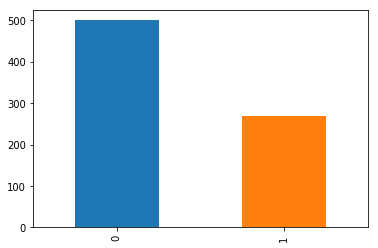

In [12]:
pima_df['class'].value_counts().plot.bar()

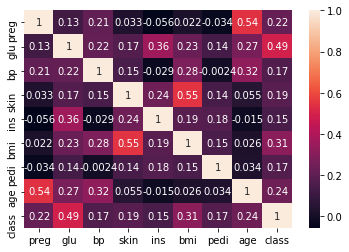

In [13]:
sns.heatmap(pima_df.corr(), annot=True)

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


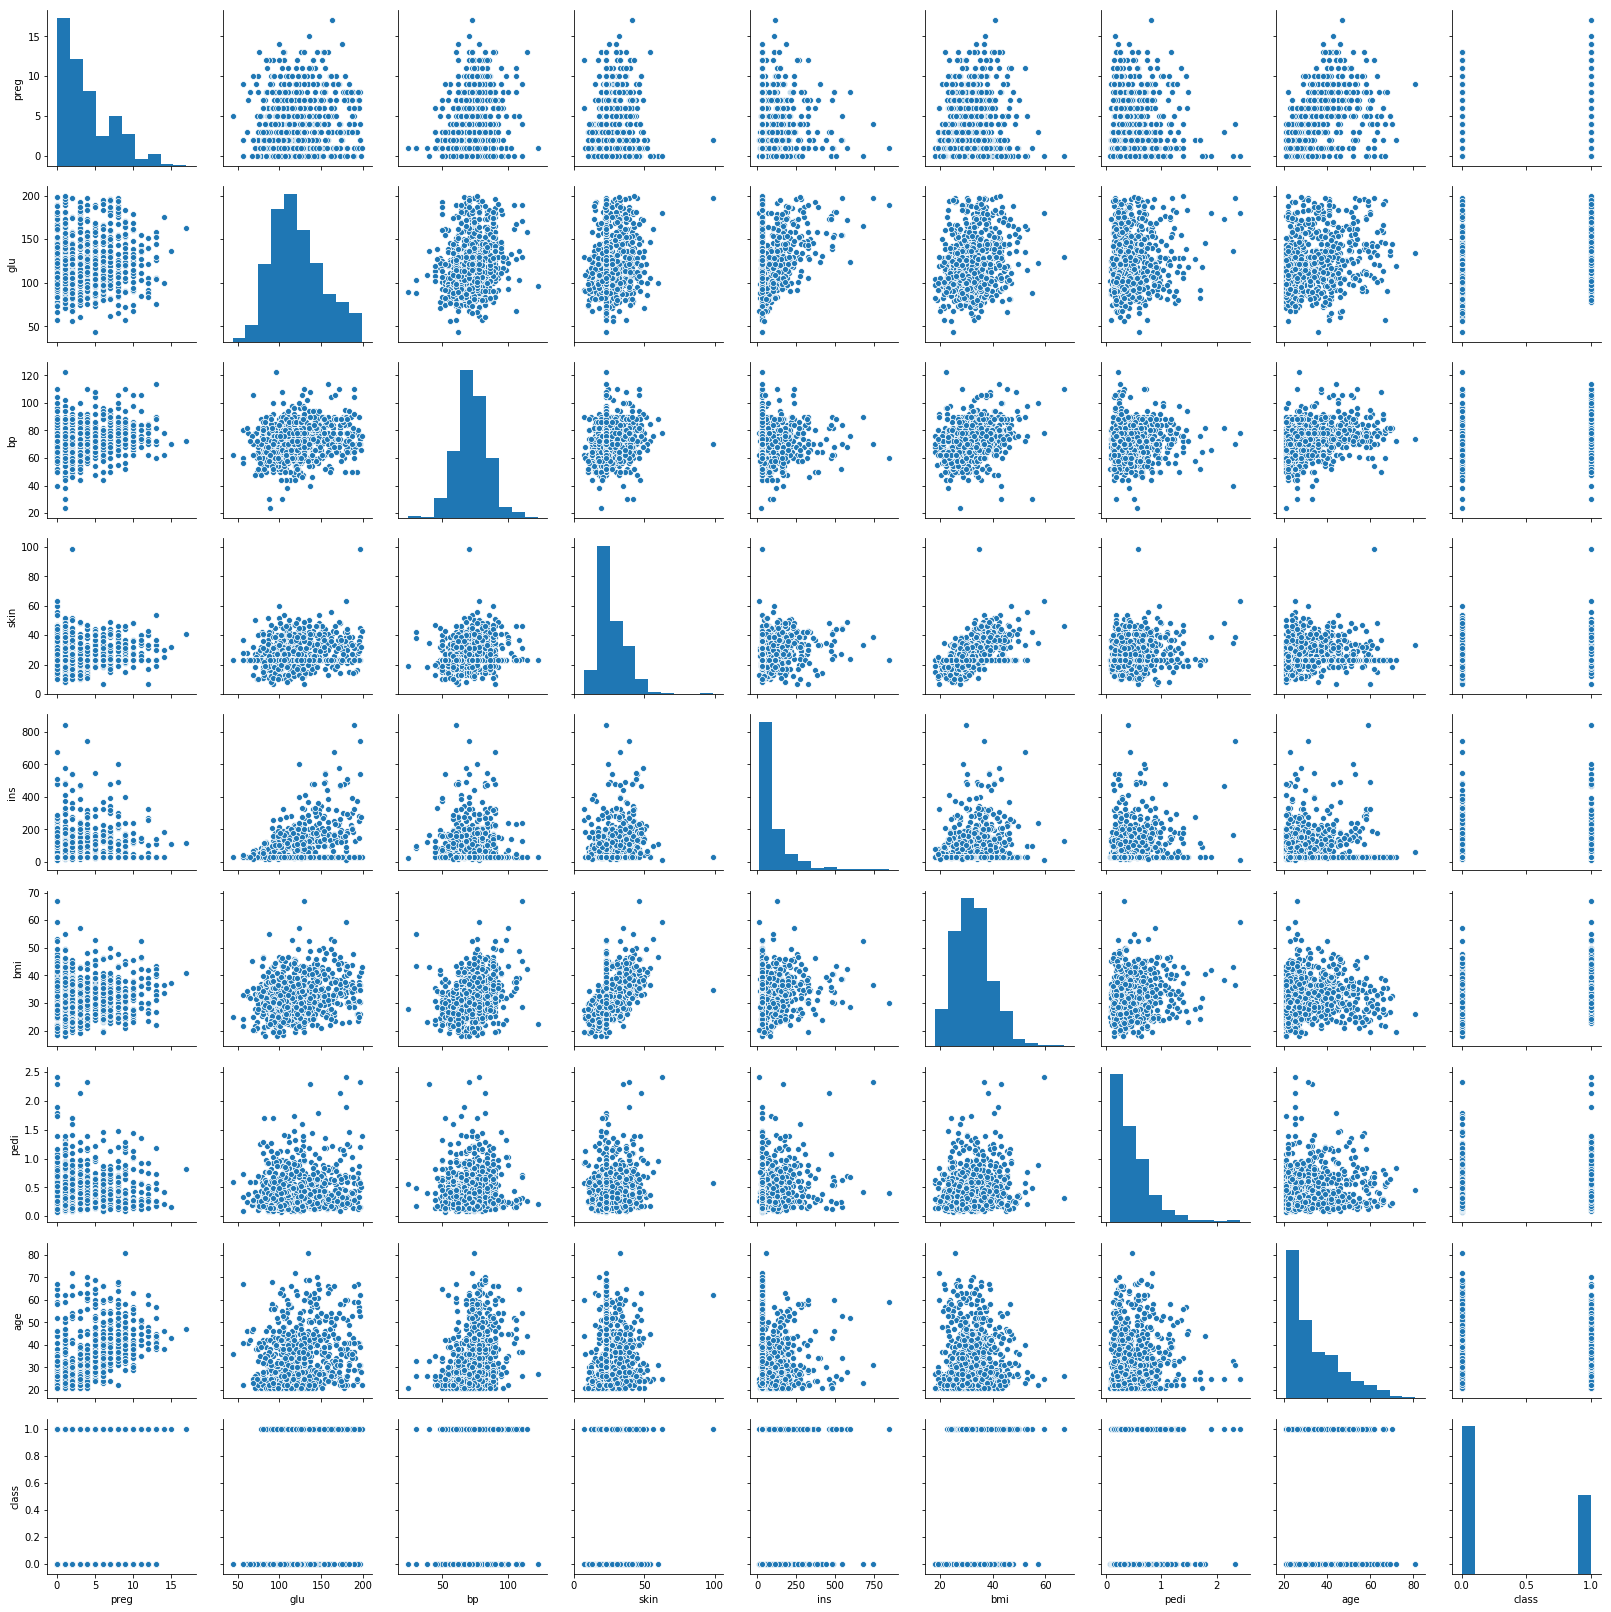

In [14]:
# Pairplot using sns to understand class distribution with every variable's
sns.pairplot(pima_df)

In [15]:
#Glucose, BMI, Age, have higher correlation with diabetic detection from teh above graph

In [16]:
pima_df.corr()

,preg,glu,bp,skin,ins,bmi,pedi,age,class
preg,1.000000,0.128213,0.208615,0.032568,-0.055697,0.021546,-0.033523,0.544341,0.221898
glu,0.128213,1.000000,0.218937,0.172143,0.357573,0.231400,0.137327,0.266909,0.492782
bp,0.208615,0.218937,1.000000,0.147809,-0.028721,0.281132,-0.002378,0.324915,0.165723
skin,0.032568,0.172143,0.147809,1.000000,0.238188,0.546951,0.142977,0.054514,0.189065
ins,-0.055697,0.357573,-0.028721,0.238188,1.000000,0.189022,0.178029,-0.015413,0.148457
bmi,0.021546,0.231400,0.281132,0.546951,0.189022,1.000000,0.153506,0.025744,0.312249
pedi,-0.033523,0.137327,-0.002378,0.142977,0.178029,0.153506,1.000000,0.033561,0.173844
age,0.544341,0.266909,0.324915,0.054514,-0.015413,0.025744,0.033561,1.000000,0.238356
class,0.221898,0.492782,0.165723,0.189065,0.148457,0.312249,0.173844,0.238356,1.000000


Using the plot - infer the relationship between different variables

In [17]:
#Glucose, BMI, Age, have higher correlation with diabetic. Pregnancy and skin variables are also related.

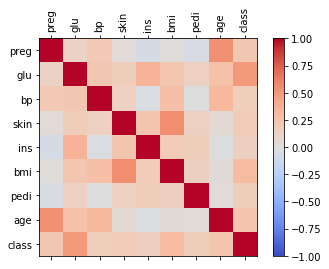

In [18]:
corr = pima_df.corr()
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(corr,cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,len(pima_df.columns),1)
ax.set_xticks(ticks)
plt.xticks(rotation=90)
ax.set_yticks(ticks)
ax.set_xticklabels(pima_df.columns)
ax.set_yticklabels(pima_df.columns)
plt.show()

In [19]:
#from the above graph, again, bmi, age, glucose are the most related variables to diabetic detection

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [20]:
X = pima_df.drop("class", axis=1)
y = pima_df["class"]
test_size = 0.3
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [21]:
dt=DecisionTreeClassifier(random_state=0)
dt.fit(X_train,y_train)
#Find the max_depth with Gridsearch
parameter={'max_depth':np.arange(1,10),'criterion' : ['entropy','gini']}
GS=GridSearchCV(dt,parameter,cv=3)
GS.fit(X,y)

GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [22]:
#max_depth from girdsearch is 4. Even from gridsearch, entropy is the best criterion

In [23]:
dt=DecisionTreeClassifier(max_depth=4,criterion='entropy',random_state=0)
dt.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

# Q10 Print the accuracy of the model & print the confusion matrix 

In [24]:
testPred=dt.predict(X_test)
metrics.accuracy_score(y_test,testPred)

0.7316017316017316

In [25]:
trainPred=dt.predict(X_train)
metrics.accuracy_score(y_train,trainPred)

0.7951582867783985

In [26]:
metrics.confusion_matrix(y_test,testPred)

array([[106,  41],
       [ 21,  63]], dtype=int64)

Print the feature importance of the decision model - Optional

In [27]:
report=metrics.classification_report(y_test,testPred)
print (pd.DataFrame(dt.feature_importances_, columns = ["Imp"], index = X_train.columns))

           Imp
preg  0.028172
glu   0.507051
bp    0.000000
skin  0.016898
ins   0.000000
bmi   0.250059
pedi  0.051113
age   0.146708


In [28]:
#from the above feature importance table: glucose, bmi and age are highly important top 3 features for detecting diabetes

# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [29]:
#chose n_estimators based on square root of number of samples
rf = RandomForestClassifier(max_depth=4,n_estimators=27,criterion='entropy',random_state=5 )
rf.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=4, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=27, n_jobs=None,
            oob_score=False, random_state=5, verbose=0, warm_start=False)

In [30]:
testPred=rf.predict(X_test)
metrics.accuracy_score(y_test,testPred)

0.7186147186147186

In [31]:
trainPred=rf.predict(X_train)
metrics.accuracy_score(y_train,trainPred)

0.8286778398510242

In [32]:
#chose n_estimators as 51 randomly
rf = RandomForestClassifier(max_depth=4, n_estimators=51,criterion='entropy',random_state=5 )
rf.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=4, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=51, n_jobs=None,
            oob_score=False, random_state=5, verbose=0, warm_start=False)

In [33]:
testPred=rf.predict(X_test)
metrics.accuracy_score(y_test,testPred)

0.7272727272727273

In [34]:
trainPred=rf.predict(X_train)
metrics.accuracy_score(y_train,trainPred)

0.8324022346368715

In [35]:
#chose n_estimators as default
rf = RandomForestClassifier(max_depth=4, n_estimators=10,criterion='entropy',random_state=5 )
rf.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=4, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=None,
            oob_score=False, random_state=5, verbose=0, warm_start=False)

In [36]:
testPred=rf.predict(X_test)
metrics.accuracy_score(y_test,testPred)

0.7445887445887446

In [37]:
trainPred=rf.predict(X_train)
metrics.accuracy_score(y_train,trainPred)

0.8119180633147114

# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [38]:
boost_rf = AdaBoostClassifier(base_estimator=rf,random_state=5)
boost_rf.fit(X_train,y_train)

AdaBoostClassifier(algorithm='SAMME.R',
          base_estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=4, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=None,
            oob_score=False, random_state=5, verbose=0, warm_start=False),
          learning_rate=1.0, n_estimators=50, random_state=5)

In [39]:
trainPred=boost_rf.predict(X_train)
metrics.accuracy_score(y_train,trainPred)

1.0

In [40]:
testPred=boost_rf.predict(X_test)
metrics.accuracy_score(y_test,testPred)

0.7402597402597403

In [41]:
#Applying adaboost ensemble algorithm on random forest, overfits the train data (in this case) and reduces the test data accuracy.

# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [42]:
#Bagging cannot be done on Randomforest. Hence do a model with a single decision tree, which has teh tendency to overfit.
base_dt=DecisionTreeClassifier(random_state=5)
bag_LR = BaggingClassifier(base_estimator=base_dt,random_state=7)
bag_LR.fit(X_train,y_train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=5,
            splitter='best'),
         bootstrap=True, bootstrap_features=False, max_features=1.0,
         max_samples=1.0, n_estimators=10, n_jobs=None, oob_score=False,
         random_state=7, verbose=0, warm_start=False)

In [43]:
base_dt.fit(X_train,y_train)
trainPred=base_dt.predict(X_train)
metrics.accuracy_score(y_train,trainPred)

1.0

In [44]:
testPred=base_dt.predict(X_test)
metrics.accuracy_score(y_test,testPred)

0.7142857142857143

In [45]:
#With single decisiontree, data is overfitted with training data and the accuracy for test data is 71.4%

In [46]:
trainPred=bag_LR.predict(X_train)
metrics.accuracy_score(y_train,trainPred)

0.9851024208566108

In [47]:
testPred=bag_LR.predict(X_test)
metrics.accuracy_score(y_test,testPred)

0.7532467532467533

In [48]:
#With bagging on single decisiontree, it is not overfitted and the accuracy for test data is improved by almost 4%

# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [49]:
gboost = GradientBoostingClassifier(n_estimators=51,random_state=2)
gboost.fit(X_train,y_train)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=51,
              n_iter_no_change=None, presort='auto', random_state=2,
              subsample=1.0, tol=0.0001, validation_fraction=0.1,
              verbose=0, warm_start=False)

In [50]:
trainPred=gboost.predict(X_train)
metrics.accuracy_score(y_train,trainPred)

0.8864059590316573

In [51]:
testPred=gboost.predict(X_test)
metrics.accuracy_score(y_test,testPred)

0.7835497835497836

In [52]:
# With gradientboost classifier algorithm, the accuracy of training set prediction is improved compared to ...
# ... some of the other methods in this assignment

# Next steps are optional and will not be graded.

In [53]:
#I am out of station. Will practice the next ones after I am back.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.

In [55]:
stacked = VotingClassifier(estimators = [('Decision Tree', dt),('RandomForest', rf), ('Boosted_RF', boost_rf), ('Log Regression', base_dt), ('Bagged LR', bag_LR), ('GradientBoost', gboost)],voting='soft')

In [56]:
stacked

VotingClassifier(estimators=[('Decision Tree', DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fr...    subsample=1.0, tol=0.0001, validation_fraction=0.1,
              verbose=0, warm_start=False))],
         flatten_transform=None, n_jobs=None, voting='soft', weights=None)